In [42]:
import torch
from torch import optim, nn, utils, Tensor
import lightning as L
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
import torchvision
print(f"Torch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Torch version: 2.10.0+cu126
Torchvision version: 0.25.0+cu126
CUDA available: True


In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Data Loading

In [44]:
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split, Subset

# 1. Define transformations for Grayscale images (1 channel)
# Augmentation for training
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]) # Simplified for grayscale
])

# Standard transforms for validation/testing
val_test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# 2. Create datasets and split indices
dataset_path = 'dataset/anuka1200'
dataset = ImageFolder(root=dataset_path, transform=val_test_transforms)

# Split indices
total_size = len(dataset)
indices = list(range(total_size))
train_indices, val_indices, test_indices = random_split(indices, [0.8, 0.1, 0.1], 
                                                        generator=torch.Generator().manual_seed(42))

# 3. Create subsets with respective transforms
train_dataset = Subset(ImageFolder(root=dataset_path, transform=train_transforms), train_indices)
val_dataset = Subset(dataset, val_indices)
test_dataset = Subset(dataset, test_indices)


# 4. Access classes and counts
print(f"Classes found: {dataset.classes}")
print(f"Number of images: {len(dataset)}")
print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}, Test size: {len(test_dataset)}")

# 5. Create DataLoaders
batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Test loading one batch
images, labels = next(iter(train_dataloader))
print(f"Batch images shape: {images.shape}")
print(f"Batch labels: {labels}")

Classes found: ['Tipo A: Kunzea', 'Tipo B: Lepto']
Number of images: 2400
Train size: 1920, Val size: 240, Test size: 240
Batch images shape: torch.Size([32, 1, 224, 224])
Batch labels: tensor([0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0,
        0, 1, 1, 1, 1, 1, 0, 1])


In [45]:
for i in train_dataloader:
    print(len(i), i[0].shape, i[1].shape)
    print(i[1])
    break

2 torch.Size([32, 1, 224, 224]) torch.Size([32])
tensor([1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1,
        0, 0, 1, 1, 0, 0, 0, 1])


# Visualization

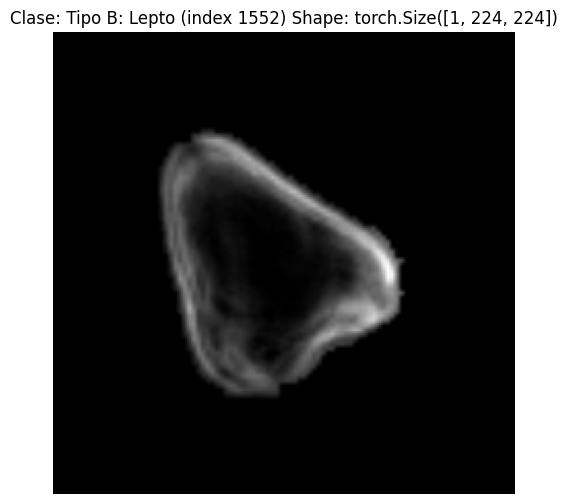

In [46]:
import matplotlib.pyplot as plt
import random
import numpy as np

# 1. Select a random index
idx = random.randint(0, len(dataset) - 1)
image, label = dataset[idx]

# 2. Un-normalize the image for visualization
mean = 0.5
std = 0.5
image_vis = image.numpy().squeeze() # (1, 224, 224) -> (224, 224)
image_vis = std * image_vis + mean
image_vis = np.clip(image_vis, 0, 1)

# 3. Display
plt.figure(figsize=(6, 6))
plt.imshow(image_vis, cmap='gray')
plt.title(f"Clase: {dataset.classes[label]} (index {idx}) Shape: {image.shape}")
plt.axis('off')
plt.show()

# Entrenamiento

## Definición del modelo.
Usaremos Pytorch Lightning, un wrapper de PyTorch que nos facilita el entrenamiento y la organización del código. Para ello, definiremos una clase que herede de `pl.LightningModule` y que implemente los métodos necesarios para el entrenamiento, validación y test.

```python

In [47]:
class RedNeuronal(L.LightningModule):
    def __init__(self, model, is_cnn=False, lr=1e-3):
        super().__init__()
        self.save_hyperparameters(ignore=['model'])
        self.model = model
        self.loss_fn = nn.BCEWithLogitsLoss()
        self.is_cnn = is_cnn
        self.lr = lr

    def training_step(self, batch, batch_idx):
        x, y = batch
        if not self.is_cnn:
            x = x.view(x.size(0), -1)  
        logits = self.model(x).squeeze(dim=1)
        y = y.float()
        loss = self.loss_fn(logits, y)
        # Calculate accuracy
        preds = (torch.sigmoid(logits) > 0.5).float()
        accuracy = (preds == y).float().mean()
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_accuracy', accuracy, prog_bar=True)
        return loss
    
    def test_step(self, batch, batch_idx):
        x, y = batch
        if not self.is_cnn:
            x = x.view(x.size(0), -1)  
        logits = self.model(x).squeeze(dim=1)
        y = y.float()
        loss = self.loss_fn(logits, y)
        preds = (torch.sigmoid(logits) > 0.5).float()
        accuracy = (preds == y).float().mean()
        self.log('test_loss', loss, prog_bar=True)
        self.log('test_accuracy', accuracy, prog_bar=True)

    def validation_step(self, batch, batch_idx):    
        x, y = batch
        if not self.is_cnn:
            x = x.view(x.size(0), -1)  
        logits = self.model(x).squeeze(dim=1)
        y = y.float()
        loss = self.loss_fn(logits, y)
        preds = (torch.sigmoid(logits) > 0.5).float()
        accuracy = (preds == y).float().mean()
        self.log('val_accuracy', accuracy, prog_bar=True)
        self.log('val_loss', loss, prog_bar=True)

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=self.lr)
        return optimizer

In [48]:
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
max_epochs = 100

## Modelo 1: NET-1 (Regresión Logística / Red Neuronal Unicapa)

In [49]:
modelo_net1 = nn.Sequential(nn.Linear(224 * 224, 1))
modelo_net1 = RedNeuronal(modelo_net1, is_cnn=False)

logger_net1 = CSVLogger("logs", name="net1")
trainer_net1 = L.Trainer(max_epochs=max_epochs, logger=logger_net1, callbacks=[EarlyStopping(monitor="val_loss", mode="min", patience=5)])
from lightning.pytorch.tuner import Tuner
tuner = Tuner(trainer_net1)
lr_finder = tuner.lr_find(modelo_net1, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)
modelo_net1.lr = lr_finder.suggestion()
print(f"Mejor LR sugerida para NET-1: {modelo_net1.lr}")
trainer_net1.fit(model=modelo_net1, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)
trainer_net1.test(model=modelo_net1, dataloaders=test_dataloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`weights_only` was not set, defaulting to `False`.


Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

LR finder stopped early after 69 steps due to diverging loss.
Restoring states from the checkpoint path at /home/diego/UNED/MineriaDeDatosUNED/PEC3/.lr_find_6d11cd1c-373e-43e1-8a6d-951e59dd30b6.ckpt
Restored all states from the checkpoint at /home/diego/UNED/MineriaDeDatosUNED/PEC3/.lr_find_6d11cd1c-373e-43e1-8a6d-951e59dd30b6.ckpt
Learning rate set to 6.3095734448019305e-06
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Mejor LR sugerida para NET-1: 6.3095734448019305e-06


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ Sequential        │ 50.2 K │ train │     0 │
│ 1 │ loss_fn │ BCEWithLogitsLoss │      0 │ train │     0 │
└───┴─────────┴───────────────────┴────────┴───────┴───────┘

...

Output()

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │     0.824999988079071     │
│         test_loss         │    0.4217420816421509     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.4217420816421509, 'test_accuracy': 0.824999988079071}]

## Modelo 2: NET-2 (Perceptrón Multicapa - MLP)

In [50]:
modelo_net2 = nn.Sequential(nn.Linear(224 * 224, 128), nn.ReLU(), nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1))
modelo_net2 = RedNeuronal(modelo_net2, is_cnn=False)

logger_net2 = CSVLogger("logs", name="net2")
trainer_net2 = L.Trainer(max_epochs=max_epochs, logger=logger_net2, callbacks=[EarlyStopping(monitor="val_loss", mode="min", patience=5)])
from lightning.pytorch.tuner import Tuner
tuner = Tuner(trainer_net2)
lr_finder = tuner.lr_find(modelo_net2, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)
modelo_net2.lr = lr_finder.suggestion()
print(f"Mejor LR sugerida para NET-2: {modelo_net2.lr}")
trainer_net2.fit(model=modelo_net2, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)
trainer_net2.test(model=modelo_net2, dataloaders=test_dataloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`weights_only` was not set, defaulting to `False`.


Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

LR finder stopped early after 81 steps due to diverging loss.
Restoring states from the checkpoint path at /home/diego/UNED/MineriaDeDatosUNED/PEC3/.lr_find_3fa26558-af80-451e-b253-3d351e5ee281.ckpt
Restored all states from the checkpoint at /home/diego/UNED/MineriaDeDatosUNED/PEC3/.lr_find_3fa26558-af80-451e-b253-3d351e5ee281.ckpt
Learning rate set to 2.2908676527677725e-05
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Mejor LR sugerida para NET-2: 2.2908676527677725e-05


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ Sequential        │  6.4 M │ train │     0 │
│ 1 │ loss_fn │ BCEWithLogitsLoss │      0 │ train │     0 │
└───┴─────────┴───────────────────┴────────┴───────┴───────┘

...

Output()

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.8374999761581421     │
│         test_loss         │    0.39602789282798767    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.39602789282798767, 'test_accuracy': 0.8374999761581421}]

## Modelo 3: CNN Simple (Base)

In [51]:
modelo_cnn = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(32 * 56 * 56, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

modelo_cnn = RedNeuronal(modelo_cnn, is_cnn=True)

logger_cnn = CSVLogger("logs", name="cnn_base")
trainer_cnn = L.Trainer(max_epochs=max_epochs, logger=logger_cnn, callbacks=[EarlyStopping(monitor="val_loss", mode="min", patience=5)])
from lightning.pytorch.tuner import Tuner
tuner = Tuner(trainer_cnn)
lr_finder = tuner.lr_find(modelo_cnn, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)
modelo_cnn.lr = lr_finder.suggestion()
print(f"Mejor LR sugerida para CNN Base: {modelo_cnn.lr}")
trainer_cnn.fit(model=modelo_cnn, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)
trainer_cnn.test(model=modelo_cnn, dataloaders=test_dataloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`weights_only` was not set, defaulting to `False`.


Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

LR finder stopped early after 91 steps due to diverging loss.
Restoring states from the checkpoint path at /home/diego/UNED/MineriaDeDatosUNED/PEC3/.lr_find_ae8aa026-5ec2-4705-8264-de406081c678.ckpt
Restored all states from the checkpoint at /home/diego/UNED/MineriaDeDatosUNED/PEC3/.lr_find_ae8aa026-5ec2-4705-8264-de406081c678.ckpt
Learning rate set to 6.3095734448019305e-06
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Mejor LR sugerida para CNN Base: 6.3095734448019305e-06


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ Sequential        │  1.6 M │ train │     0 │
│ 1 │ loss_fn │ BCEWithLogitsLoss │      0 │ train │     0 │
└───┴─────────┴───────────────────┴────────┴───────┴───────┘

...

Output()

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.8166666626930237     │
│         test_loss         │    0.5122047066688538     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.5122047066688538, 'test_accuracy': 0.8166666626930237}]

## Modelo 4: CNN Variante A (BatchNorm + Dropout)

In [52]:
modelo_cnn_a = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding=1),
    nn.BatchNorm2d(16),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(32 * 56 * 56, 16),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(16, 1)
)

modelo_cnn_a = RedNeuronal(modelo_cnn_a, is_cnn=True)

logger_cnn_a = CSVLogger("logs", name="cnn_var_a")
trainer_cnn_a = L.Trainer(max_epochs=max_epochs, logger=logger_cnn_a, callbacks=[EarlyStopping(monitor="val_loss", mode="min", patience=5)])
from lightning.pytorch.tuner import Tuner
tuner = Tuner(trainer_cnn_a)
lr_finder = tuner.lr_find(modelo_cnn_a, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)
modelo_cnn_a.lr = lr_finder.suggestion()
print(f"Mejor LR sugerida para CNN Variante A: {modelo_cnn_a.lr}")
trainer_cnn_a.fit(model=modelo_cnn_a, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)
trainer_cnn_a.test(model=modelo_cnn_a, dataloaders=test_dataloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`weights_only` was not set, defaulting to `False`.


Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=100` reached.
Restoring states from the checkpoint path at /home/diego/UNED/MineriaDeDatosUNED/PEC3/.lr_find_848d18c3-c915-4cb6-a0f0-53b2daf5c0f0.ckpt
Restored all states from the checkpoint at /home/diego/UNED/MineriaDeDatosUNED/PEC3/.lr_find_848d18c3-c915-4cb6-a0f0-53b2daf5c0f0.ckpt
Learning rate set to 3.0199517204020163e-06
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Mejor LR sugerida para CNN Variante A: 3.0199517204020163e-06


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ Sequential        │  1.6 M │ train │     0 │
│ 1 │ loss_fn │ BCEWithLogitsLoss │      0 │ train │     0 │
└───┴─────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 1.6 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.6 M                                                                                                
Total estimated model params size (MB): 6                                                                          
Modules in train mode: 15                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

## Modelo 5: CNN Variante B (Más profunda con canales 64 y Dropout)

In [ ]:
modelo_cnn_b = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(64 * 28 * 28, 64),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(64, 1)
)

modelo_cnn_b = RedNeuronal(modelo_cnn_b, is_cnn=True)

logger_cnn_b = CSVLogger("logs", name="cnn_var_b")
trainer_cnn_b = L.Trainer(max_epochs=max_epochs, logger=logger_cnn_b, callbacks=[EarlyStopping(monitor="val_loss", mode="min", patience=5)])
from lightning.pytorch.tuner import Tuner
tuner = Tuner(trainer_cnn_b)
lr_finder = tuner.lr_find(modelo_cnn_b, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)
modelo_cnn_b.lr = lr_finder.suggestion()
print(f"Mejor LR sugerida para CNN Variante B: {modelo_cnn_b.lr}")
trainer_cnn_b.fit(model=modelo_cnn_b, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)
trainer_cnn_b.test(model=modelo_cnn_b, dataloaders=test_dataloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ Sequential        │  3.2 M │ train │     0 │
│ 1 │ loss_fn │ BCEWithLogitsLoss │      0 │ train │     0 │
└───┴─────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 3.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.2 M                                                                                                
Total estimated model params size (MB): 12                                                                         
Modules in train mode: 16                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/home/diego/.pyenv/versions/3.13.3/envs/MineriaDeDatos/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
